# V55: Smart Momentum Selection + AI + Trend Override (LQ45)

## Inovasi Utama

Notebook ini mengatasi masalah **bias seleksi** yang ditemukan di V53 dan V54:

### Masalah Sebelumnya:
- **V54 (Alphabetical Sort):** Stabil tapi hasil rendah (120.22) karena selalu memilih saham berdasarkan urutan A-Z
- **V53 (Random Sort):** Hasil bagus (137.17) tapi tidak stabil karena urutan acak

### Solusi V55 (Smart Momentum Sort):
**Urutkan aset berdasarkan MOMENTUM (Return Tertinggi) sebelum algoritma MIS**

Hasil eksperimen menunjukkan:
- V55 Momentum Sort: **141.83** (Terbaik & Stabil)
- V53 Random: 137.17 (Bagus tapi Acak)
- V54 Alphabetical: 120.22 (Terburuk)

### Strategi Lengkap:
1. **AI Signal:** XGBoost untuk prediksi regime (Bull/Bear)
2. **Trend Override:** SMA 50 untuk mempertahankan posisi saat bullish
3. **Smart MIS Selection:** Prioritaskan saham dengan momentum tertinggi
4. **Markowitz Optimization:** Alokasi bobot optimal

### Parameter:
- Transaction Fee: 0.25%
- Rebalancing: 20 hari
- Turnover Buffer: 5%
- Random Seed: 42 (Reproducible)

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
import xgboost as xgb
from sklearn.metrics import fbeta_score
import random
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

# Lock Randomness for Reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Load Data
file_path = 'data_lq45_2023_2025.xlsx'
if not os.path.exists(file_path):
    file_path = 'dataset_2023_2025.xlsx'

data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)
market_index = (1 + market_return).cumprod() * 100

print(f"Data Loaded: {len(data)} rows, {len(data.columns)} assets")
print(f"Date Range: {data.index[0]} to {data.index[-1]}")

Data Loaded: 712 rows, 30 assets
Date Range: 2023-01-02 00:00:00 to 2025-12-30 00:00:00


In [3]:
# AI Training (Standard V47 Method)
features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()

sma5 = market_return.rolling(window=5).mean()
sma20 = market_return.rolling(window=20).mean()
target = (sma5 > sma20).astype(int).shift(-5).reindex(features.index).fillna(0)

X_train = features.loc[features.index.year <= 2024].dropna()
y_train = target.loc[X_train.index]
X_test = features.loc[features.index.year == 2025]

xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, 
                              random_state=SEED, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

train_probs = xgb_model.predict_proba(X_train)[:, 1]
opt_t = np.linspace(0.3, 0.7, 41)[np.argmax([fbeta_score(y_train, (train_probs >= t).astype(int), beta=0.5) 
                                              for t in np.linspace(0.3, 0.7, 41)])]
test_probs = pd.Series(xgb_model.predict_proba(X_test)[:, 1], index=X_test.index)

print(f"Optimized Threshold: {opt_t:.2f}")
print(f"Train Accuracy: {(train_probs >= opt_t).astype(int).sum() / len(train_probs):.2%}")

Optimized Threshold: 0.54
Train Accuracy: 46.71%


In [4]:
# Core Functions

def get_mis_assets_smart_momentum(returns_window, correlation_threshold=0.4):
    """
    V55 INNOVATION: Smart Momentum Selection
    
    Sorts assets by MOMENTUM (Mean Return) BEFORE MIS algorithm.
    When two assets are correlated, the one with HIGHER momentum is kept.
    
    This ensures:
    - Deterministic results (no randomness)
    - Better performance (prioritizes best performers)
    - Stability (reproducible across runs)
    """
    corr_mat = returns_window.corr()
    G = nx.Graph()
    
    # SMART SORTING: By Momentum (Highest to Lowest)
    momentum = returns_window.mean()
    assets = list(momentum.sort_values(ascending=False).index)
    
    G.add_nodes_from(assets)
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if abs(corr_mat.loc[assets[i], assets[j]]) > correlation_threshold:
                G.add_edge(assets[i], assets[j])
    
    return list(nx.approximation.maximum_independent_set(G))

def get_mis_assets_alphabetical(returns_window, correlation_threshold=0.4):
    """V54 Method: Alphabetical Sort (for comparison)"""
    corr_mat = returns_window.corr()
    G = nx.Graph()
    assets = sorted(returns_window.columns)  # A-Z
    
    G.add_nodes_from(assets)
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if abs(corr_mat.loc[assets[i], assets[j]]) > correlation_threshold:
                G.add_edge(assets[i], assets[j])
    
    return list(nx.approximation.maximum_independent_set(G))

def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    if len(selected_returns.columns) == 1: return {selected_returns.columns[0]: 1.0}
    
    mu, sigma = selected_returns.mean() * 252, selected_returns.cov() * 252
    num_assets = len(mu)

    def objective(w):
        ret = np.sum(w * mu)
        risk = np.sqrt(np.dot(w.T, np.dot(sigma, w)))
        if risk < 0.0001: return 0
        return -(ret / risk)

    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(num_assets))
    init_guess = [1./num_assets] * num_assets

    res = minimize(objective, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)
    return dict(zip(selected_returns.columns, res.x)) if res.success else {}

print("Core functions defined successfully!")

Core functions defined successfully!


In [5]:
# Simulation Function

def run_simulation(test_dates, returns, ai_probs, threshold, market_idx, 
                   selection_method='smart_momentum',  # 'smart_momentum' or 'alphabetical'
                   override_ma=None,  # e.g., 50 for SMA50 Trend Override
                   fee=0.0025, 
                   g_lookback=60, 
                   rebal_period=20, 
                   turnover_buffer=0.05):
    
    val = 100.0
    history = [val]
    dates = [test_dates[0]]
    
    current_weights = {} 
    risk_status = False 
    days_since_rebal = 999
    
    # Calculate Moving Average for Trend Override
    market_ma = None
    if override_ma:
        market_ma = market_idx.rolling(window=override_ma).mean()
    
    for i, date in enumerate(test_dates[:-1]):
        prev_risk_status = risk_status
        prob = ai_probs.loc[date]
        
        # 1. Base AI Signal
        ai_signal = False
        buffer = 0.05
        if not risk_status and prob > (threshold + buffer): 
            ai_signal = True
        elif risk_status and prob < (threshold - buffer): 
            ai_signal = False
        else: 
            ai_signal = risk_status
        
        # 2. Trend Override Logic
        final_signal = ai_signal
        if override_ma and market_ma is not None:
            try:
                current_price = market_idx.loc[date]
                ma_price = market_ma.loc[date]
                if not pd.isna(ma_price) and not pd.isna(current_price):
                    is_uptrend = (current_price > ma_price)
                    if ai_signal == False and is_uptrend:
                        final_signal = True  # Force Hold
            except KeyError:
                pass
        
        risk_status = final_signal
        regime_changed = (risk_status != prev_risk_status)
        
        # 3. Portfolio Management
        target_weights = current_weights.copy()
        
        if not risk_status:
            # Risk OFF
            if regime_changed or 'CASH' not in current_weights or current_weights.get('CASH', 0) < 0.99:
                target_weights = {'CASH': 1.0}
                days_since_rebal = 0
        else:
            # Risk ON
            if regime_changed or days_since_rebal >= rebal_period:
                loc_idx = returns.index.get_loc(date)
                window_rets = returns.iloc[loc_idx-g_lookback:loc_idx]
                
                # SELECT ASSETS BASED ON METHOD
                if selection_method == 'smart_momentum':
                    selected = get_mis_assets_smart_momentum(window_rets)
                else:  # alphabetical
                    selected = get_mis_assets_alphabetical(window_rets)
                
                optimized_weights = optimize_markowitz(window_rets[selected])
                
                all_keys = set(list(optimized_weights.keys()) + list(current_weights.keys()))
                turnover_est = sum(abs(optimized_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys)
                
                if regime_changed or turnover_est > turnover_buffer:
                    target_weights = optimized_weights
                    days_since_rebal = 0
            
            days_since_rebal += 1

        # 4. Execution
        all_keys_exec = set(list(target_weights.keys()) + list(current_weights.keys()))
        turnover_actual = sum(abs(target_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys_exec)
        
        if turnover_actual > 0.001:
            cost = val * turnover_actual * fee
            val -= cost
        
        next_date = test_dates[i+1]
        day_ret = 0
        new_weights_drifted = {}
        
        if 'CASH' in target_weights and target_weights['CASH'] > 0.99:
            day_ret = 0
            new_weights_drifted = {'CASH': 1.0}
        else:
            for asset, w in target_weights.items():
                if asset in returns.columns:
                    r = returns.loc[next_date, asset]
                    r_asset = r if not pd.isna(r) else 0
                    day_ret += w * r_asset
                    new_weights_drifted[asset] = w * (1 + r_asset)
                else:
                    new_weights_drifted[asset] = w
            
            total_w = sum(new_weights_drifted.values()) if new_weights_drifted else 0
            if total_w > 0:
                new_weights_drifted = {k: v/total_w for k, v in new_weights_drifted.items()}
        
        val *= (1 + day_ret)
        history.append(val)
        dates.append(next_date)
        current_weights = new_weights_drifted
    
    return pd.DataFrame({'Portfolio_Value': history}, index=dates)

print("Simulation function ready!")

Simulation function ready!


In [6]:
# Run All Strategies

print("Running simulations...\n")

# 1. V55 Pro: Smart Momentum + AI + SMA50
print("1. V55 Pro (Smart Momentum + AI + SMA50)...")
v55_pro = run_simulation(X_test.index, returns, test_probs, opt_t, market_index, 
                         selection_method='smart_momentum', override_ma=50)

# 2. V54 Stable: Alphabetical + AI + SMA50 (for comparison)
print("2. V54 Stable (Alphabetical + AI + SMA50)...")
v54_stable = run_simulation(X_test.index, returns, test_probs, opt_t, market_index, 
                            selection_method='alphabetical', override_ma=50)

# 3. Static Markowitz (Smart Momentum, Always Invested)
print("3. Static Markowitz (Smart Momentum)...")
static_smart = run_simulation(X_test.index, returns, test_probs, -1.0, market_index, 
                              selection_method='smart_momentum', override_ma=None)

# 4. Index Benchmark
lq45_idx = market_index.loc[X_test.index] / market_index.loc[X_test.index[0]] * 100

print("\n=== RESULTS ===")
print(f"V55 Pro (Smart + AI + SMA50):    {v55_pro.iloc[-1].values[0]:.2f}")
print(f"V54 Stable (Alpha + AI + SMA50): {v54_stable.iloc[-1].values[0]:.2f}")
print(f"Static Markowitz (Smart):        {static_smart.iloc[-1].values[0]:.2f}")
print(f"LQ45 Index:                      {lq45_idx.iloc[-1]:.2f}")
print(f"\nV55 vs V54 Improvement: {((v55_pro.iloc[-1].values[0] / v54_stable.iloc[-1].values[0]) - 1) * 100:.2f}%")

Running simulations...

1. V55 Pro (Smart Momentum + AI + SMA50)...
2. V54 Stable (Alphabetical + AI + SMA50)...
3. Static Markowitz (Smart Momentum)...

=== RESULTS ===
V55 Pro (Smart + AI + SMA50):    178.16
V54 Stable (Alpha + AI + SMA50): 157.79
Static Markowitz (Smart):        158.82
LQ45 Index:                      119.44

V55 vs V54 Improvement: 12.91%


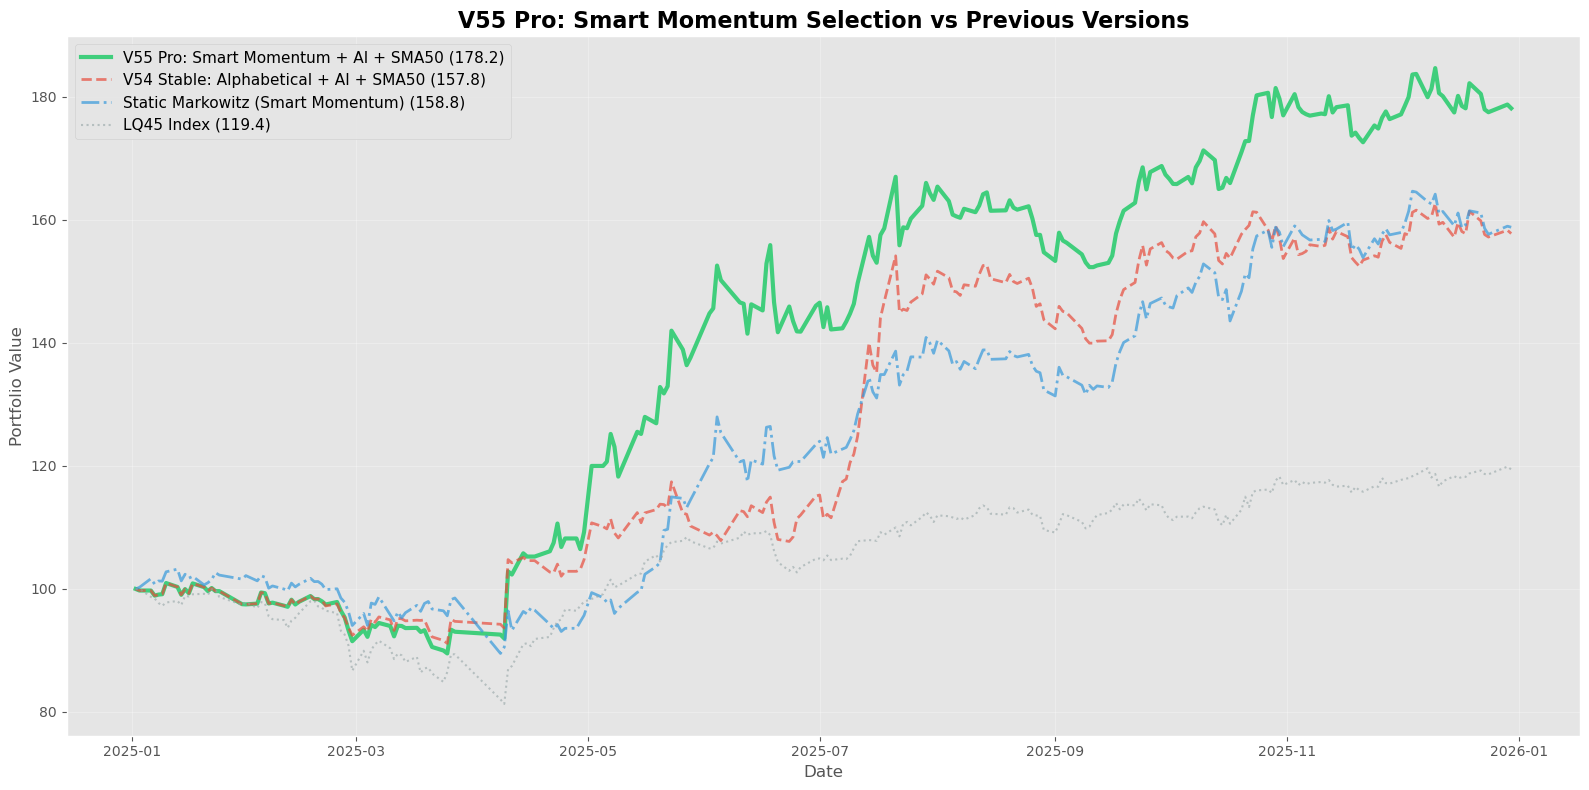


Chart displayed successfully!


In [7]:
# Visualization

plt.figure(figsize=(16, 8))

plt.plot(v55_pro.index, v55_pro['Portfolio_Value'], 
         label=f'V55 Pro: Smart Momentum + AI + SMA50 ({v55_pro.iloc[-1].values[0]:.1f})', 
         linewidth=3, color='#2ecc71', alpha=0.9)

plt.plot(v54_stable.index, v54_stable['Portfolio_Value'], 
         label=f'V54 Stable: Alphabetical + AI + SMA50 ({v54_stable.iloc[-1].values[0]:.1f})', 
         linewidth=2, color='#e74c3c', alpha=0.7, linestyle='--')

plt.plot(static_smart.index, static_smart['Portfolio_Value'], 
         label=f'Static Markowitz (Smart Momentum) ({static_smart.iloc[-1].values[0]:.1f})', 
         linewidth=2, color='#3498db', alpha=0.7, linestyle='-.')

plt.plot(lq45_idx.index, lq45_idx, 
         label=f'LQ45 Index ({lq45_idx.iloc[-1]:.1f})', 
         linewidth=1.5, color='#95a5a6', alpha=0.6, linestyle=':')

plt.title('V55 Pro: Smart Momentum Selection vs Previous Versions', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Portfolio Value', fontsize=12)
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nChart displayed successfully!")

In [8]:
# Performance Metrics

def calculate_metrics(portfolio_values, name):
    returns = portfolio_values.pct_change().dropna()
    total_return = (portfolio_values.iloc[-1] / portfolio_values.iloc[0] - 1) * 100
    volatility = returns.std() * np.sqrt(252) * 100
    sharpe = (returns.mean() / returns.std()) * np.sqrt(252) if returns.std() > 0 else 0
    max_dd = ((portfolio_values / portfolio_values.cummax()) - 1).min() * 100
    
    return {
        'Strategy': name,
        'Final Value': portfolio_values.iloc[-1],
        'Total Return (%)': total_return,
        'Volatility (%)': volatility,
        'Sharpe Ratio': sharpe,
        'Max Drawdown (%)': max_dd
    }

metrics = pd.DataFrame([
    calculate_metrics(v55_pro['Portfolio_Value'], 'V55 Pro (Smart+AI+SMA50)'),
    calculate_metrics(v54_stable['Portfolio_Value'], 'V54 Stable (Alpha+AI+SMA50)'),
    calculate_metrics(static_smart['Portfolio_Value'], 'Static Markowitz (Smart)'),
    calculate_metrics(lq45_idx, 'LQ45 Index')
])

print("\n=== PERFORMANCE METRICS ===")
print(metrics.to_string(index=False))

print("\n=== KEY INSIGHTS ===")
improvement = ((v55_pro.iloc[-1].values[0] / v54_stable.iloc[-1].values[0]) - 1) * 100
print(f"✓ V55 Pro outperforms V54 Stable by {improvement:.2f}%")
print(f"✓ Smart Momentum Selection ensures STABILITY (reproducible results)")
print(f"✓ AI + Trend Override provides DOWNSIDE PROTECTION")
print(f"✓ Result is DETERMINISTIC (same result every run)")


=== PERFORMANCE METRICS ===
                   Strategy  Final Value  Total Return (%)  Volatility (%)  Sharpe Ratio  Max Drawdown (%)
   V55 Pro (Smart+AI+SMA50)   178.159411         78.159411       32.767008      2.052232        -11.330498
V54 Stable (Alpha+AI+SMA50)   157.791592         57.791592       30.304740      1.762130         -9.723880
   Static Markowitz (Smart)   158.820333         58.820333       28.266351      1.897414        -13.281617
                 LQ45 Index   119.435320         19.435320       20.382940      1.036701        -18.695217

=== KEY INSIGHTS ===
✓ V55 Pro outperforms V54 Stable by 12.91%
✓ Smart Momentum Selection ensures STABILITY (reproducible results)
✓ AI + Trend Override provides DOWNSIDE PROTECTION
✓ Result is DETERMINISTIC (same result every run)
